In [13]:
%config InlineBackend.figure_format = 'retina'

In [14]:
from common import *

In [15]:
df = read_trace("Qwen3-0.6B-32/1.csv")
df.head(n=30)

,type,timestamp_us,count,layer_idx,seq_len,token_idx
0,StartTracing,0,<NA>,<NA>,<NA>,<NA>
1,CheckpointBegin,1001859,<NA>,<NA>,<NA>,<NA>
2,CheckpointMetadata,1002050,<NA>,<NA>,<NA>,<NA>
3,CheckpointFilesOpen,1002083,<NA>,<NA>,<NA>,<NA>
4,CheckpointHCacheWrite,1002284,<NA>,<NA>,<NA>,<NA>
5,CheckpointKVCacheWrite,1002744,<NA>,<NA>,<NA>,<NA>
6,CheckpointFlush,1002749,<NA>,<NA>,<NA>,<NA>
7,CheckpointFsyncData,1006094,<NA>,<NA>,<NA>,<NA>
8,CheckpointWatermark,1008042,<NA>,<NA>,<NA>,<NA>
9,CheckpointComplete,1008043,0,<NA>,<NA>,<NA>


In [26]:
def match_begin_end_events(df, begin_type, end_type, event_type, end_cols=[], by_cols=[]):
    """
    Match begin and end events and calculate durations.
    
    Parameters:
    -----------
    df : DataFrame
        The trace dataframe
    begin_type : str
        Event type for begin events
    end_type : str
        Event type for end events
    event_type : str
        Name for the event type (e.g., 'checkpoint', 'layer')
    end_cols : list, optional
        Additional columns to include from end events (e.g., ['count'])
    by_cols : list, optional
        Columns to match on in addition to timestamp (e.g., ['layer_idx', 'seq_len', 'token_idx'])
    
    Returns:
    --------
    DataFrame with begin_timestamp, end_timestamp, duration_us, event_type, and any additional columns
    """
    # Filter and prepare dataframes
    end_cols_list = ['timestamp_us'] + [c for c in end_cols if c in df.columns] + [c for c in by_cols if c in df.columns]
    begin_cols_list = ['timestamp_us'] + [c for c in by_cols if c in df.columns]
    ends = df[df['type'] == end_type][end_cols_list]
    begins = df[df['type'] == begin_type][begin_cols_list].rename(columns={'timestamp_us': 'begin_timestamp'})
    
    # Merge to find corresponding begin for each end
    merged = pd.merge_asof(
        ends, begins,
        left_on='timestamp_us', right_on='begin_timestamp',
        by=by_cols if by_cols else None,
        direction='backward'
    )
    
    # Calculate duration and add event type
    merged = merged.rename(columns={'timestamp_us': 'end_timestamp'})
    merged['duration_us'] = merged['end_timestamp'] - merged['begin_timestamp']
    merged['event_type'] = event_type
    
    return merged

# Match checkpoint end events with their corresponding begin events
checkpoint_df = match_begin_end_events(df, 'CheckpointBegin', 'CheckpointComplete', 'checkpoint', end_cols=['count'])
checkpoint_df.head(50)

,end_timestamp,count,begin_timestamp,duration_us,event_type
0,1008043,0,1001859,6184,checkpoint
1,2564572,64,2554840,9732,checkpoint
2,2611428,32,2602055,9373,checkpoint
3,2658458,32,2648789,9669,checkpoint
4,2705844,32,2696499,9345,checkpoint
5,2760035,32,2743032,17003,checkpoint
6,2806488,32,2797143,9345,checkpoint
7,2852803,32,2843721,9082,checkpoint
8,2899393,32,2890071,9322,checkpoint
9,2946131,32,2936490,9641,checkpoint


In [17]:
layer_df = match_begin_end_events(
    df, "LayerBegin", "LayerComplete", "layer", by_cols=["layer_idx", "seq_len", "token_idx"]
)
layer_df

,end_timestamp,layer_idx,seq_len,token_idx,begin_timestamp,duration_us,event_type
0,2554741,0,32,0,2514626,40115,layer
1,2601968,1,32,0,2564593,37375,layer
2,2648691,2,32,0,2611446,37245,layer
3,2696400,3,32,0,2658481,37919,layer
4,2742935,4,32,0,2705860,37075,layer
...,...,...,...,...,...,...,...
1899,25464826,23,1,431,25462463,2363,layer
1900,25467247,24,1,431,25464839,2408,layer
1901,25469659,25,1,431,25467259,2400,layer
1902,25472043,26,1,431,25469671,2372,layer


In [18]:
# Match state load events
state_load_df = match_begin_end_events(df, 'StateLoadBegin', 'StateLoadComplete', 'state_load')
state_load_df

,end_timestamp,begin_timestamp,duration_us,event_type


In [19]:
# Match model load events
model_load_df = match_begin_end_events(df, 'ModelLoadBegin', 'ModelLoadComplete', 'model_load')
model_load_df

,end_timestamp,begin_timestamp,duration_us,event_type
0,2505312,1008085,1497227,model_load


In [20]:
# Merge all dataframes, sort by end_timestamp
merged_df = pd.concat(
    [checkpoint_df, layer_df, state_load_df, model_load_df], 
    ignore_index=True
).sort_values('end_timestamp').reset_index(drop=True)
merged_df['duration_ms'] = merged_df['duration_us'] / 1000
merged_df.head(n=30)

,end_timestamp,count,begin_timestamp,duration_us,event_type,layer_idx,seq_len,token_idx,duration_ms
0,1008043,0,1001859,6184,checkpoint,<NA>,<NA>,<NA>,6.184
1,2505312,<NA>,1008085,1497227,model_load,<NA>,<NA>,<NA>,1497.227
2,2554741,<NA>,2514626,40115,layer,0,32,0,40.115
3,2564572,64,2554840,9732,checkpoint,<NA>,<NA>,<NA>,9.732
4,2601968,<NA>,2564593,37375,layer,1,32,0,37.375
5,2611428,32,2602055,9373,checkpoint,<NA>,<NA>,<NA>,9.373
6,2648691,<NA>,2611446,37245,layer,2,32,0,37.245
7,2658458,32,2648789,9669,checkpoint,<NA>,<NA>,<NA>,9.669
8,2696400,<NA>,2658481,37919,layer,3,32,0,37.919
9,2705844,32,2696499,9345,checkpoint,<NA>,<NA>,<NA>,9.345


In [21]:
def analyze_event_breakdown(df, event_prefix, begin_suffix='Begin', id_name=None):
    """
    Analyze the breakdown of events with a common prefix (e.g., 'Checkpoint', 'StateLoad').
    
    Parameters:
    -----------
    df : DataFrame
        The trace dataframe
    event_prefix : str
        Prefix of events to analyze (e.g., 'Checkpoint', 'StateLoad')
    begin_suffix : str, optional
        Suffix for begin events (default: 'Begin')
    id_name : str, optional
        Name for the ID column (default: f'{event_prefix.lower()}_id')
    
    Returns:
    --------
    DataFrame with breakdown showing time_to_begin and time_to_previous for each event
    """
    id_name = id_name or f'{event_prefix.lower()}_id'
    begin_type = f'{event_prefix}{begin_suffix}'
    
    # Filter events and assign group IDs
    events = df[df['type'].str.startswith(event_prefix)].sort_values('timestamp_us')
    begins = events[events['type'] == begin_type].copy()
    begins[id_name] = range(len(begins))
    
    # Assign each event to its corresponding begin group
    events = pd.merge_asof(
        events, begins[['timestamp_us', id_name]],
        on='timestamp_us', direction='backward'
    ).dropna(subset=[id_name])
    events[id_name] = events[id_name].astype(int)
    
    # Calculate time_to_begin and time_to_previous for each event group
    def process_group(group):
        group = group.sort_values('timestamp_us')
        begin_ts = group[group['type'] == begin_type]['timestamp_us'].iloc[0]
        
        timestamps = group['timestamp_us'].values
        time_to_begin = timestamps - begin_ts
        time_to_previous = np.concatenate([[0], np.diff(timestamps)])
        
        return {etype: (t2b, t2p) for etype, t2b, t2p in 
                zip(group['type'], time_to_begin, time_to_previous)}
    
    results = events.groupby(id_name, sort=True).apply(process_group).tolist()
    
    return pd.DataFrame(results) if results else pd.DataFrame()

# Analyze checkpoint breakdown
checkpoint_analysis_df = analyze_event_breakdown(df, 'Checkpoint')
checkpoint_analysis_df

/tmp/ipykernel_327250/2413377177.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = events.groupby(id_name, sort=True).apply(process_group).tolist()


,CheckpointBegin,CheckpointMetadata,CheckpointFilesOpen,CheckpointHCacheWrite,CheckpointKVCacheWrite,CheckpointFlush,CheckpointFsyncData,CheckpointWatermark,CheckpointComplete
0,"(0, 0)","(191, 191)","(224, 33)","(425, 201)","(885, 460)","(890, 5)","(4235, 3345)","(6183, 1948)","(6184, 1)"
1,"(0, 0)","(436, 436)","(477, 41)","(940, 463)","(1901, 961)","(1902, 1)","(8120, 6218)","(9730, 1610)","(9732, 2)"
2,"(0, 0)","(451, 451)","(492, 41)","(810, 318)","(1810, 1000)","(1811, 1)","(7587, 5776)","(9371, 1784)","(9373, 2)"
3,"(0, 0)","(456, 456)","(494, 38)","(820, 326)","(1816, 996)","(1817, 1)","(7971, 6154)","(9667, 1696)","(9669, 2)"
4,"(0, 0)","(382, 382)","(420, 38)","(752, 332)","(1752, 0)","(1752, 1000)","(7591, 5839)","(9345, 1754)","(9345, 0)"
...,...,...,...,...,...,...,...,...,...
400,"(0, 0)","(418, 418)","(461, 43)","(755, 294)","(4138, 3383)","(4157, 19)","(16119, 11962)","(17843, 1724)","(17844, 1)"
401,"(0, 0)","(424, 424)","(464, 40)","(757, 293)","(4124, 3367)","(4144, 20)","(17112, 12968)","(18846, 1734)","(18847, 1)"
402,"(0, 0)","(414, 414)","(457, 43)","(740, 283)","(4109, 3369)","(4130, 21)","(15932, 11802)","(17592, 1660)","(17592, 0)"
403,"(0, 0)","(403, 403)","(439, 36)","(731, 292)","(4086, 3355)","(4115, 29)","(16138, 12023)","(17840, 1702)","(17841, 1)"


(<Figure size 500.093x309.075 with 1 Axes>, <Axes: >)

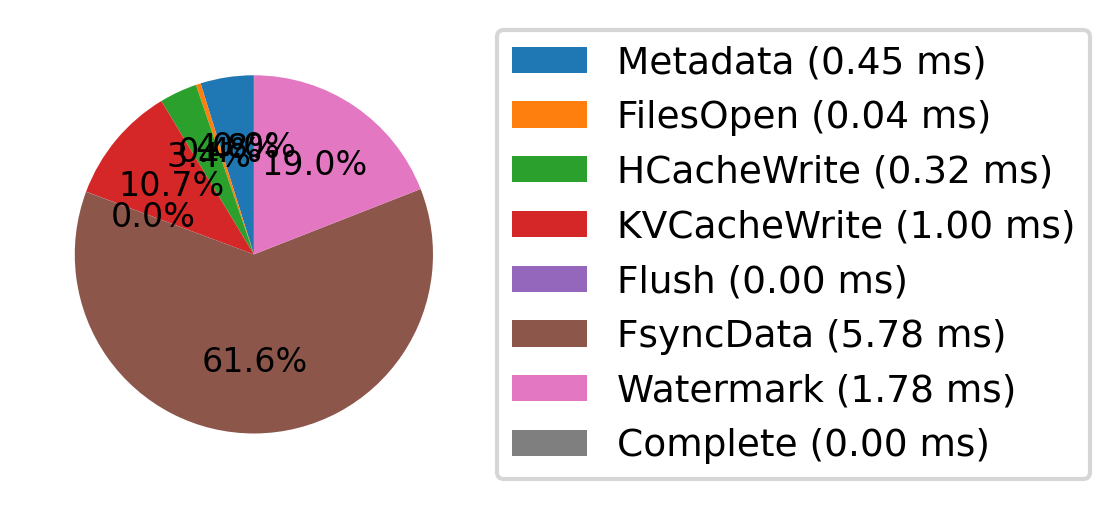

In [22]:
def plot_event_pie(row, event_prefix):
    """Plot a pie chart showing the cost breakdown of each component for an event group."""
    components = []
    times = []
    
    for col, value in row.items():
        if pd.notna(value):
            _, time_to_previous = value
            component_name = col.replace(event_prefix, '')
            if component_name != 'Begin' and time_to_previous > 0:
                components.append(component_name)
                times.append(time_to_previous)
    
    fig, ax = plt.subplots(figsize=figsize)
    wedges, texts, autotexts = ax.pie(
        times, 
        labels=None,  # No labels on pie slices
        autopct='%1.1f%%', 
        startangle=90,
        textprops={'fontsize': font_size - 1}
    )
    
    # Use legend instead of labels to avoid overlap
    ax.legend(wedges, [f'{c} ({t/1000:.2f} ms)' for c, t in zip(components, times)],
              loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=font_size)
    
    plt.tight_layout()
    return fig, ax

# Example: plot pie chart for first checkpoint
plot_event_pie(checkpoint_analysis_df.iloc[2], 'Checkpoint')

In [23]:
# Analyze state load breakdown
state_load_analysis_df = analyze_event_breakdown(df, 'StateLoad')
state_load_analysis_df

/tmp/ipykernel_327250/2413377177.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = events.groupby(id_name, sort=True).apply(process_group).tolist()


AttributeError: 'DataFrame' object has no attribute 'tolist'

In [ ]:
# Example: plot pie chart for first state load
plot_event_pie(state_load_analysis_df.iloc[0], 'StateLoad')

NameError: name 'state_load_analysis_df' is not defined